# Prior Predictive Check — obtención con preliz y máxima entropía

**Referencias**:

- **PreliZ — *Direct elicitation of 1D priors*** \
  https://preliz.readthedocs.io/en/latest/examples/gallery/direct_elicitation_1D.html
- **EABM (ArviZ) — *Prior and posterior predictive checks*** \
  https://arviz-devs.github.io/EABM/Chapters/Prior_posterior_predictive_checks.html

## 1. Fundamentos matemáticos

### 1.1 La distribución prior predictive

El *prior predictive* es la distribución marginal de los datos antes de observar nada, integrando la verosimilitud sobre la incertidumbre a priori en los parámetros:

$$
p(y) \;=\; \int p(y \mid \theta)\, p(\theta)\, d\theta
$$

El procedimiento según (EABM, capítulo 6) tiene cinco pasos:

1. Muestrear $\theta^{(s)} \sim p(\theta)$ para $s = 1,\dots,S$.
2. Para cada $\theta^{(s)}$, simular $y^{(s)} \sim p(y \mid \theta^{(s)})$.
3. Visualizar la distribución de $\{y^{(s)}\}$.
4. Comparar contra **conocimiento del dominio**.
5. Si hay discrepancia, ajustar el prior y repetir.

### 1.2 Principio de máxima entropía

Dada una familia paramétrica $\mathcal{F}$ y un conjunto de restricciones $\mathcal{C}$, el principio de máxima entropía (Jaynes, 1957) elige la distribución $p \in \mathcal{F}$ que satisface $\mathcal{C}$ y maximiza la entropía de Shannon:

$$
p^\ast \;=\; \arg\max_{p \in \mathcal{F}} \; H[p] \;=\; \arg\max_{p \in \mathcal{F}} \; -\!\int p(x) \log p(x)\, dx
\quad\text{sujeto a } \mathcal{C}
$$

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import preliz as pz

from config import (
    SEED, PARAMS_CALIBRATED, PLAUSIBILITY_RANGES,
)

plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(SEED)

print(f"preliz {pz.__version__}")
print("\nValores calibrados de referencia (no se inyectan en el prior — sólo para contextualizar):")
for k in ["r", "alpha", "a", "b"]:
    print(f"  {k:5s} = {PARAMS_CALIBRATED[k]:.3f}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


preliz 0.24.0

Valores calibrados de referencia (no se inyectan en el prior — sólo para contextualizar):
  r     = 8.248
  alpha = 2.041
  a     = 0.269
  b     = 19.731


## 2. Obtención de las priors con `pz.maxent`

Para cada uno de los cuatro parámetros $(r, \alpha, a, b)$ aportamos un intervalo plausible basado en conocimiento del dominio (transporte público granadino + literatura BTYD) y una masa objetivo del 94 %.

**Familia elegida: Gamma para los cuatro.** Es no negativa (acorde a la naturaleza de los parámetros), tiene dos parámetros que dan flexibilidad para la maxent, y es la opción natural en `pymc-marketing.clv.BetaGeoModel`.

**Justificación de los intervalos:**

| Parámetro | Intervalo plausible | Razón |
|---|---|---|
| $r$       | $[1,\, 25]$       | Forma de Gamma para $\lambda$. En literatura BTYD $r \in [0.5, 20]$ es típico; el intervalo cubre desde alta a baja heterogeneidad. |
| $\alpha$  | $[0.3,\, 8]$    | Escala de Gamma. Combinado con $r$ debe dar $\mathbb{E}[\lambda] = r/\alpha \in [0.5,\, 20]$ viajes/semana. |
| $a$       | $[0.05,\, 2]$   | Beta de abandono. Valor pequeño codifica baja prob. de abandono. |
| $b$       | $[3,\, 60]$       | Beta de permanencia. Combinado con $a$ debe dar $\mathbb{E}[p] = a/(a+b) \in [0.001,\, 0.1]$. |

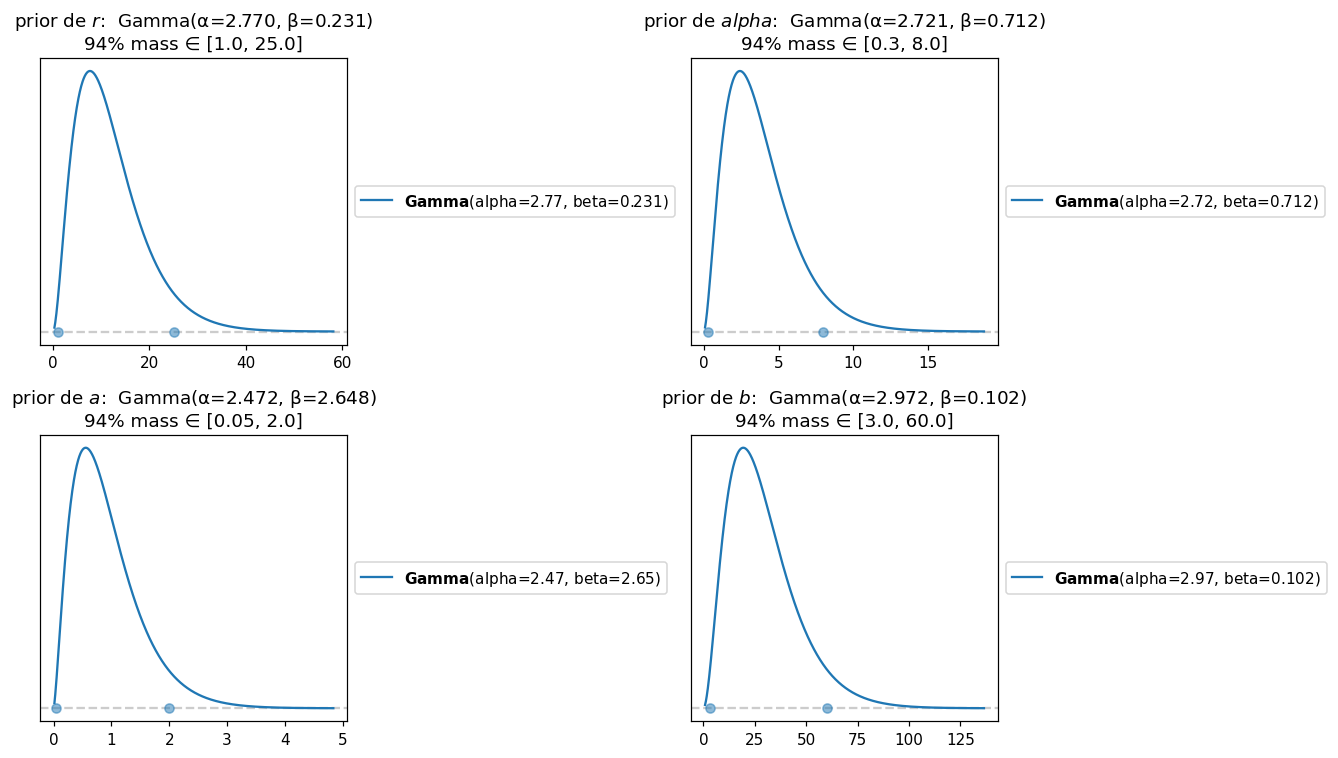

In [2]:
# Intervalos de plausibilidad por parámetro (lower, upper, mass)
INTERVALOS = {
    "r":     (1.0,  25.0, 0.94),
    "alpha": (0.3,   8.0, 0.94),
    "a":     (0.05,  2.0, 0.94),
    "b":     (3.0,  60.0, 0.94),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
elicitados: dict[str, pz.Gamma] = {}

for ax, (nombre, (lo, hi, m)) in zip(axes.ravel(), INTERVALOS.items()):
    plt.sca(ax)
    dist = pz.Gamma()
    pz.maxent(dist, lower=lo, upper=hi, mass=m, plot=True)
    elicitados[nombre] = dist
    ax.set_title(f"prior de ${nombre}$:  Gamma(α={dist.alpha:.3f}, β={dist.beta:.3f})\n"
                  f"94% mass ∈ [{lo}, {hi}]")

plt.tight_layout()
plt.show()

In [3]:
# Tabla resumen — parámetros de las priors elicitadas
filas = []
for nombre, dist in elicitados.items():
    filas.append({
        "parámetro":      nombre,
        "familia":        "Gamma",
        "α (shape)":      dist.alpha,
        "β (rate)":       dist.beta,
        "E[·]":           dist.mean(),
        "std[·]":         dist.std(),
        "valor calibrado": PARAMS_CALIBRATED[nombre],
    })

tabla = pd.DataFrame(filas)
print("Priors elicitadas por máxima entropía:")
print(tabla.to_string(index=False, formatters={
    "α (shape)":       "{:.4f}".format,
    "β (rate)":        "{:.4f}".format,
    "E[·]":            "{:.3f}".format,
    "std[·]":          "{:.3f}".format,
    "valor calibrado": "{:.3f}".format,
}))

# Empaquetar en el formato pymc-marketing
PRIORS_ELICITED = {
    nombre: {"dist": "Gamma",
             "kwargs": {"alpha": float(dist.alpha), "beta": float(dist.beta)}}
    for nombre, dist in elicitados.items()
}

print("\nPRIORS_ELICITED (formato pymc-marketing):")
for k, v in PRIORS_ELICITED.items():
    print(f"  {k:6s}: {v}")

Priors elicitadas por máxima entropía:
parámetro familia α (shape) β (rate)   E[·] std[·] valor calibrado
        r   Gamma    2.7703   0.2312 11.984  7.200           8.248
    alpha   Gamma    2.7206   0.7124  3.819  2.315           2.041
        a   Gamma    2.4715   2.6485  0.933  0.594           0.269
        b   Gamma    2.9717   0.1017 29.234 16.958          19.731

PRIORS_ELICITED (formato pymc-marketing — copiar a config.PRIORS['elicited']):
  r     : {'dist': 'Gamma', 'kwargs': {'alpha': 2.7703429907433734, 'beta': 0.23117430744647322}}
  alpha : {'dist': 'Gamma', 'kwargs': {'alpha': 2.720551442100849, 'beta': 0.7124474317785369}}
  a     : {'dist': 'Gamma', 'kwargs': {'alpha': 2.471507382063672, 'beta': 2.6484526929362717}}
  b     : {'dist': 'Gamma', 'kwargs': {'alpha': 2.971738560479212, 'beta': 0.1016538034195523}}


## 3. Prior predictive: simulación del modelo BG/NBD

Implementamos la fórmula $p(y) = \int p(y \mid \theta)\,p(\theta)\,d\theta$ por Monte Carlo:

1. **Muestreo del prior conjunto.** Sortear $S$ tuplas $(r^{(s)}, \alpha^{(s)}, a^{(s)}, b^{(s)})$, una por cada prior obtenida. Como las priors son independientes, $p(\theta) = p(r)\,p(\alpha)\,p(a)\,p(b)$.

2. **Simulación de la verosimilitud.** Para cada $\theta^{(s)}$ y para cada usuario $i = 1,\dots,n$:
   - $\lambda_i^{(s)} \sim \mathrm{Gamma}(r^{(s)}, \alpha^{(s)})$
   - $p_i^{(s)} \sim \mathrm{Beta}(a^{(s)}, b^{(s)})$
   - Generar la trayectoria BG/NBD con $T$ semanas y registrar $(x, t_x, T, z)$.

3. **Comparación con conocimiento del dominio.** Las distribuciones de las cantidades observables ($x$, $z$) y de las cantidades interpretables ($\mathbb{E}[\lambda]$, $\mathbb{E}[p]$) deben caer en las franjas plausibles de `config.PLAUSIBILITY_RANGES`.

In [4]:
def simular_usuario_bgnbd(lam, p, T, rng):
    """Simulador BG/NBD por usuario."""
    vivo, primera, ultima, activas, viajes = True, None, None, 0, 0
    p_eff = min(max(p, 0.0), 1.0)
    for t in range(T):
        if not vivo:
            break
        n = rng.poisson(lam)
        if n > 0:
            if primera is None:
                primera = t
            ultima = t
            activas += 1
            viajes += n
            if rng.random() < p_eff:
                vivo = False
    if primera is None:
        return 0, 0.0, T, 0.0
    return activas - 1, float(ultima - primera), float(T - primera), viajes / max(activas, 1)


def prior_predictive(elicitados, n_users=200, T=150, S=60, rng=None):
    """Implementación Monte Carlo de p(y) = ∫ p(y|θ) p(θ) dθ."""
    rng = rng or np.random.default_rng(SEED)
    filas = []
    for s in range(S):
        # Paso 1: muestreo del prior conjunto
        r     = elicitados["r"].rvs(random_state=rng)
        alpha = elicitados["alpha"].rvs(random_state=rng)
        a     = elicitados["a"].rvs(random_state=rng)
        b     = elicitados["b"].rvs(random_state=rng)

        # Paso 2: muestreo de la verosimilitud para n usuarios
        lam_arr = rng.gamma(shape=r, scale=1/alpha, size=n_users)
        p_arr   = rng.beta(a=a, b=b, size=n_users)
        for lam, p in zip(lam_arr, p_arr):
            x, tx, Tu, z = simular_usuario_bgnbd(lam, p, T, rng)
            filas.append((s, r, alpha, a, b, lam, p, x, tx, Tu, z))

    return pd.DataFrame(filas, columns=[
        "sample", "r", "alpha", "a", "b",
        "lambda", "p", "frequency", "recency", "T", "monetary_value",
    ])


import time
t0 = time.time()
ppc = prior_predictive(elicitados, n_users=200, T=150, S=60)
ppc["E_lambda"] = ppc["r"] / ppc["alpha"]
ppc["E_p"]      = ppc["a"] / (ppc["a"] + ppc["b"])
print(f"Prior predictive: {len(ppc):,} usuarios simulados en {time.time()-t0:.1f} s")

Prior predictive: 12,000 usuarios simulados en 1.7 s


## 4. Diagnóstico — ¿los priors son razonables?

Siguiendo el principio del paso 4 de EABM: comparamos las distribuciones simuladas contra los **rangos plausibles** del dominio (no contra los datos observados). La condición de aceptación: que la mayoría de la masa caiga dentro de la franja verde.

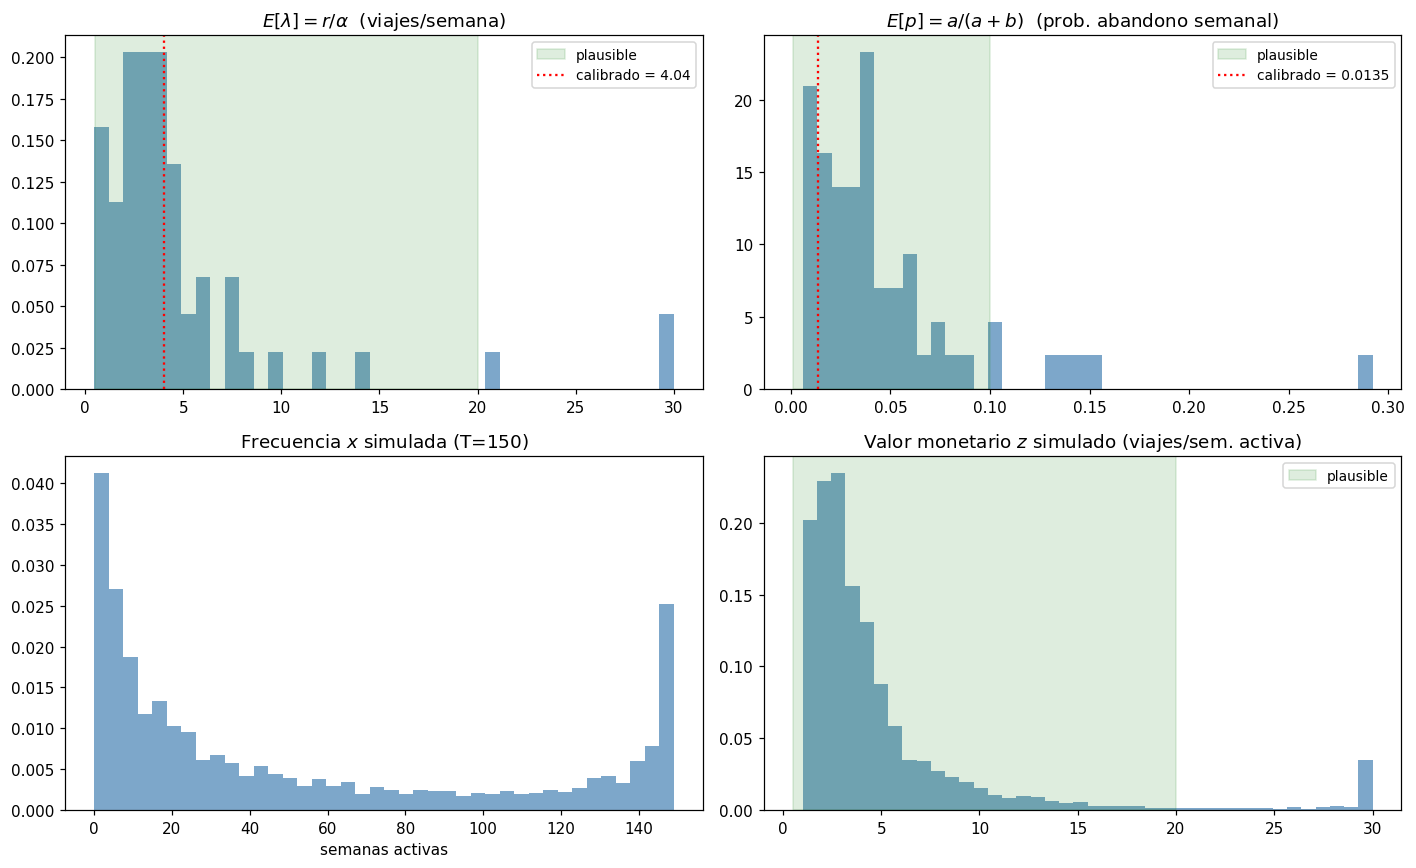


Cobertura del prior predictive contra el dominio:
                           métrica % prior
                  E[λ] ∈ plausible   91.7%
                  E[p] ∈ plausible   88.3%
              monetary ∈ plausible   95.9%
prob. p > 0.5 (abandona >50%/sem.)    0.4%
prob. λ > 50 (más de 7 viajes/día)    0.1%


In [5]:
lam_lo, lam_hi = PLAUSIBILITY_RANGES["E_lambda"]
p_lo,   p_hi   = PLAUSIBILITY_RANGES["E_p"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (a) E[λ] implícita
ax = axes[0, 0]
ax.hist(ppc["E_lambda"].clip(0, 30), bins=40, density=True, color="steelblue", alpha=0.7)
ax.axvspan(lam_lo, lam_hi, color="forestgreen", alpha=0.15, label="plausible")
ax.axvline(PARAMS_CALIBRATED["E_lambda"], color="red", ls=":",
           label=f"calibrado = {PARAMS_CALIBRATED['E_lambda']:.2f}")
ax.set_title("$E[\\lambda] = r/\\alpha$  (viajes/semana)")
ax.legend(fontsize=9)

# (b) E[p] implícita
ax = axes[0, 1]
ax.hist(ppc["E_p"], bins=40, density=True, color="steelblue", alpha=0.7)
ax.axvspan(p_lo, p_hi, color="forestgreen", alpha=0.15, label="plausible")
ax.axvline(PARAMS_CALIBRATED["E_p"], color="red", ls=":",
           label=f"calibrado = {PARAMS_CALIBRATED['E_p']:.4f}")
ax.set_title("$E[p] = a/(a+b)$  (prob. abandono semanal)")
ax.legend(fontsize=9)

# (c) Frecuencia simulada
ax = axes[1, 0]
ax.hist(ppc["frequency"].clip(0, 150), bins=40, density=True, color="steelblue", alpha=0.7)
ax.set_title("Frecuencia $x$ simulada (T=150)")
ax.set_xlabel("semanas activas")

# (d) Valor monetario simulado
ax = axes[1, 1]
ax.hist(ppc["monetary_value"].clip(0, 30), bins=40, density=True, color="steelblue", alpha=0.7)
ax.axvspan(*PLAUSIBILITY_RANGES["monetary_value"], color="forestgreen", alpha=0.15,
           label="plausible")
ax.set_title("Valor monetario $z$ simulado (viajes/sem. activa)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(r'C:\Users\andre\OneDrive\Documentos\UGR\tfm-clv-transporte-granada\docs\figures\prior_predictive.pdf')
plt.show()

# Cobertura cuantitativa
checks = pd.DataFrame([
    {"métrica": "E[λ] ∈ plausible",
     "% prior": ((ppc["E_lambda"] >= lam_lo) & (ppc["E_lambda"] <= lam_hi)).mean()},
    {"métrica": "E[p] ∈ plausible",
     "% prior": ((ppc["E_p"] >= p_lo) & (ppc["E_p"] <= p_hi)).mean()},
    {"métrica": "monetary ∈ plausible",
     "% prior": ((ppc["monetary_value"] >= PLAUSIBILITY_RANGES["monetary_value"][0]) &
                 (ppc["monetary_value"] <= PLAUSIBILITY_RANGES["monetary_value"][1])).mean()},
    {"métrica": "prob. p > 0.5 (abandona >50%/sem.)",
     "% prior": (ppc["p"] > 0.5).mean()},
    {"métrica": "prob. λ > 50 (más de 7 viajes/día)",
     "% prior": (ppc["lambda"] > 50).mean()},
])
checks["% prior"] = checks["% prior"].map("{:.1%}".format)
print("\nCobertura del prior predictive contra el dominio:")
print(checks.to_string(index=False))